---

<img src="https://user-images.githubusercontent.com/7065401/67041620-66491080-f0fc-11e9-9fff-68f3c079a4b0.png"
    style="width:350px; float: right; margin: 0 40px 40px 40px;"></img>

# Plotting with Pandas

The pandas library has become popular not just for enabling powerful data analysis, but also for its handy pre-canned plotting methods. Interestingly though, pandas plotting methods are really just convenient wrappers around existing matplotlib calls.

That is, the `plot()` method on pandas’ Series and DataFrame is a wrapper around `plt.plot()`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Pandas can easily read data stored in different file formats like CSV, JSON, XML or even Excel as we saw on the previous lecture.

Let's read some data and plot some basic figures.

In [2]:
# load data
df = pd.read_csv('nba_data.csv')

# show first rows
df.head()

,Rk,Player,Position,Age,Mp,Fg,Fga,Fg%,3P,3Pa,...,Team,Gp,Mpg,Orpm,Drpm,Rpm,Wins_Rpm,Pie,Pace,W
0,1,Russell Westbrook,PG,28,34.6,10.2,24.0,0.425,2.5,7.2,...,OKC,81,34.6,6.74,-0.47,6.27,17.34,23.0,102.31,46
1,2,James Harden,PG,27,36.4,8.3,18.9,0.440,3.2,9.3,...,HOU,81,36.4,6.38,-1.57,4.81,15.54,19.0,102.98,54
2,3,Isaiah Thomas,PG,27,33.8,9.0,19.4,0.463,3.2,8.5,...,BOS,76,33.8,5.72,-3.89,1.83,8.19,16.1,99.84,51
3,4,Anthony Davis,C,23,36.1,10.3,20.3,0.505,0.5,1.8,...,NO,75,36.1,0.45,3.90,4.35,12.81,19.2,100.19,31
4,5,DeMar DeRozan,SG,27,35.4,9.7,20.9,0.467,0.4,1.7,...,TOR,74,35.4,2.21,-2.04,0.17,5.46,15.5,97.69,47


---

## Scatter plot

We'll use `Fg` and `Fga` to draw a **scatter plot** and see the relation between both columns.

<Axes: xlabel='Fg', ylabel='Fga'>

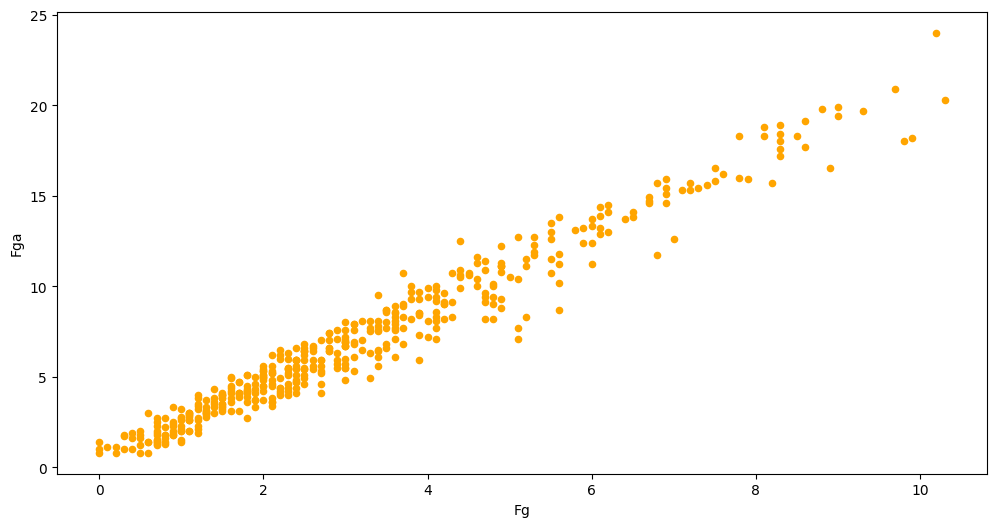

In [3]:
df.plot(kind='scatter',
        x= 'Fg',
        y= 'Fga',
        color='orange',
        figsize=(12, 6))

<Axes: xlabel='Fg', ylabel='Fga'>

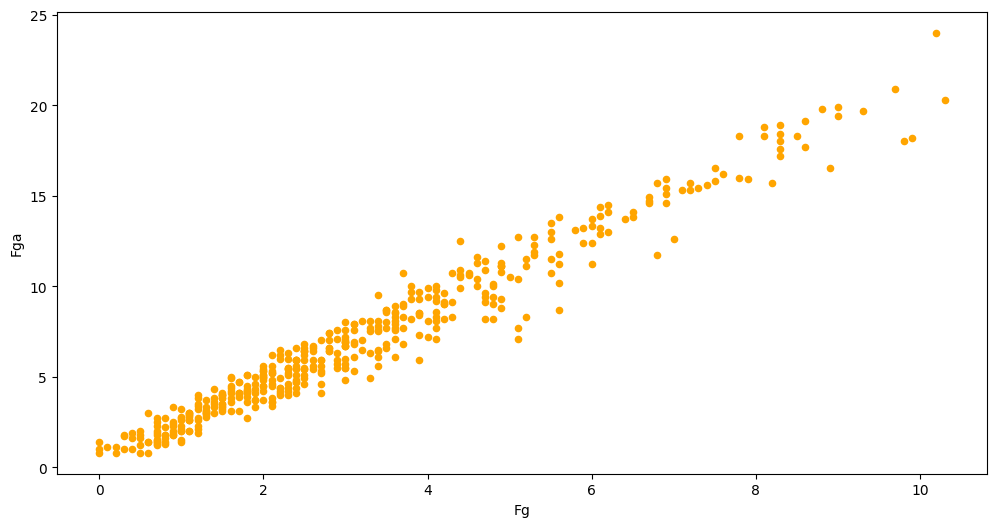

In [4]:
df.plot.scatter(x='Fg',
                y='Fga',
                color='orange',
               figsize=(12, 6))

Now let's see relation between `Fg` and `Age`:

<Axes: xlabel='Fg', ylabel='Age'>

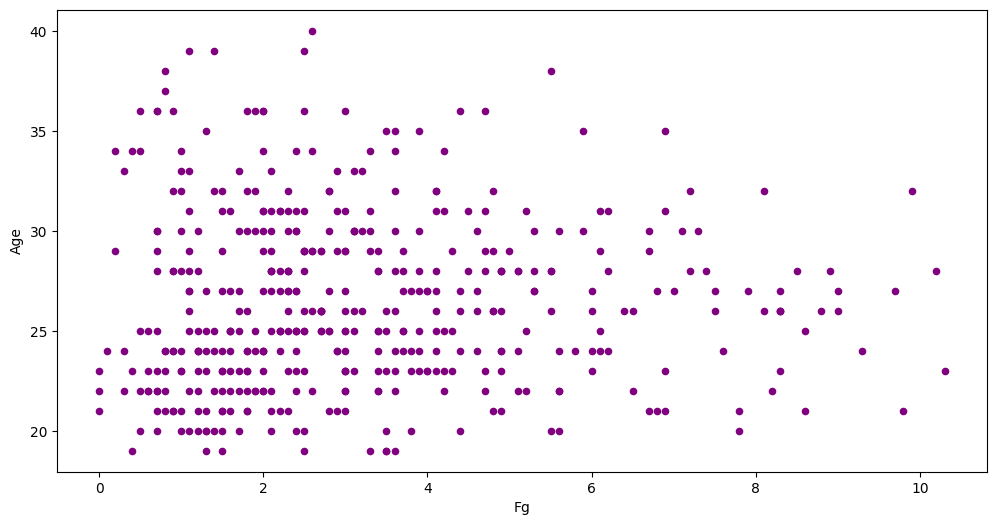

In [5]:
df.plot(kind='scatter',
        x='Fg',
        y='Age',
        color='purple',
        figsize=(12, 6))



## Bar plot

We can also make some nice **bar plots**. Let's see the age of the first 10 players:

In [6]:
df.head(10)['Age']

0    28
1    27
2    27
3    23
4    27
5    26
6    26
7    32
8    25
9    28
Name: Age, dtype: int64

<Axes: xlabel='Player'>

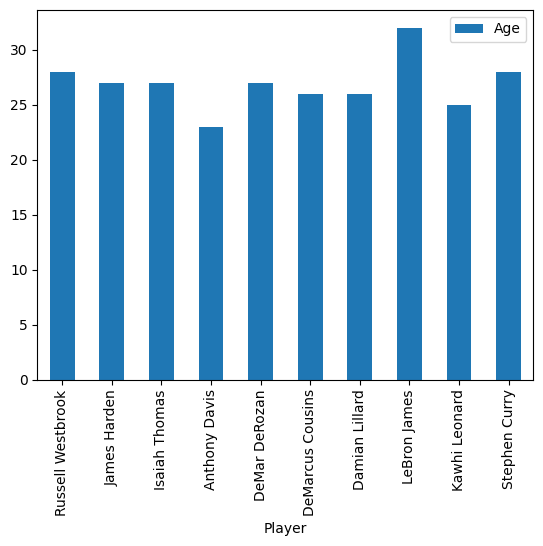

In [7]:
df.head(10).plot(kind='bar',
                 x='Player',
                 y='Age')

<Axes: xlabel='Player'>

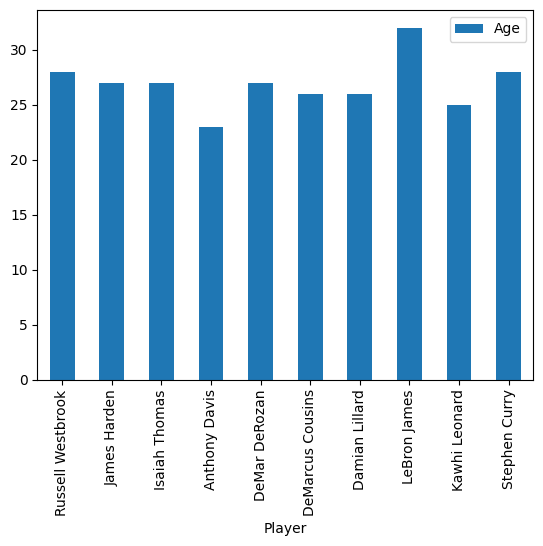

In [8]:
df.head(10).plot.bar(x='Player',
                     y='Age')

<Axes: >

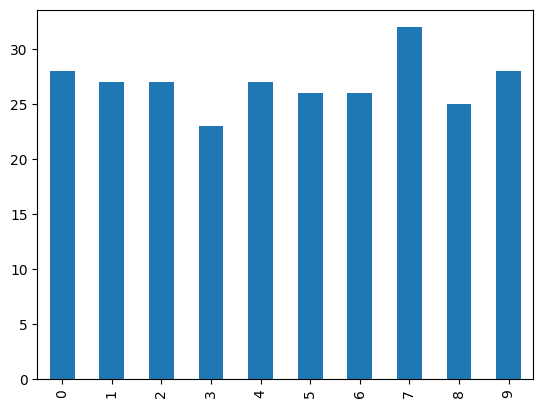

In [9]:
df.head(10)['Age'].plot(kind='bar')

Also is possible with columns without numeric values:

In [10]:
df['Position'].value_counts()

Position
PF      94
PG      93
C       90
SG      90
SF      78
PF-C     1
Name: count, dtype: int64

<Axes: xlabel='Position'>

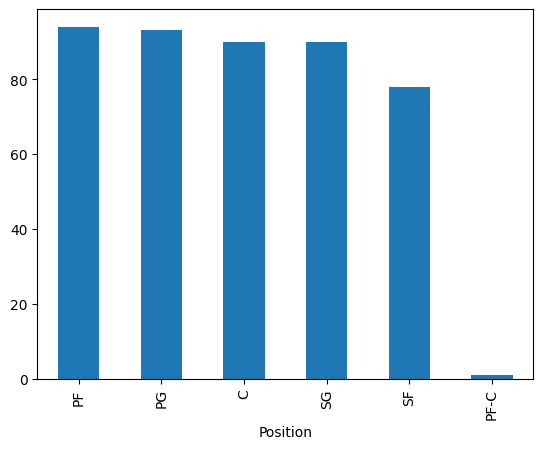

In [11]:
df['Position'].value_counts().plot(kind='bar')


## Line plot

Another useful type of plot is the **line plot**.

<Axes: xlabel='Player'>

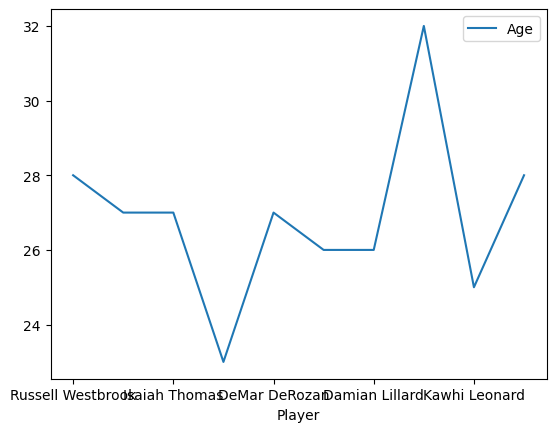

In [12]:
df.head(10).plot(kind='line',
                 x='Player',
                 y='Age')



## Pie plot

In order to see the fractional area of different values within a column, we can make a **pie plot**.

<Axes: title={'center': 'FG per Player'}, ylabel='Fg'>

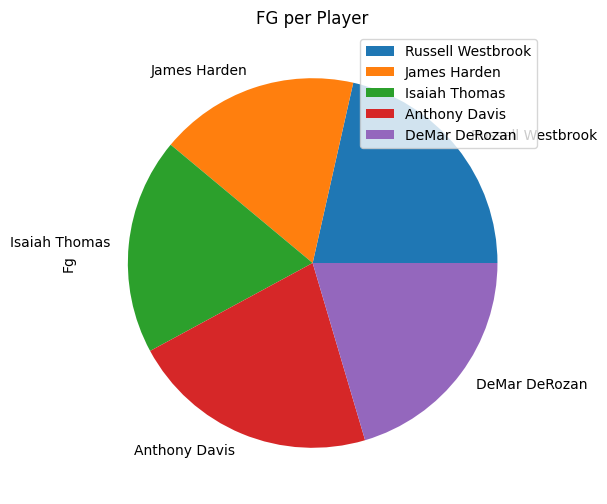

In [13]:
df.head(5)['Fg'].plot(kind='pie',
                      labels=df['Player'],
                      title='FG per Player',
                      legend=True,
                      figsize=(6,6))

Also is possible with columns without numeric values:

In [14]:
df['Position'].value_counts()

Position
PF      94
PG      93
C       90
SG      90
SF      78
PF-C     1
Name: count, dtype: int64

<Axes: ylabel='count'>

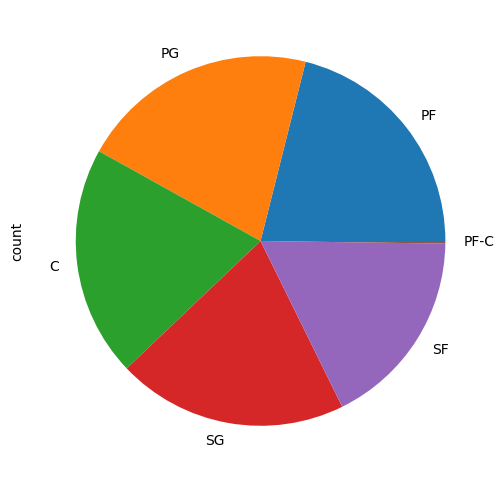

In [15]:
df['Position'].value_counts().plot(kind='pie', figsize=(6,6))



## Histogram

Histograms can also be drawn.

<Axes: ylabel='Frequency'>

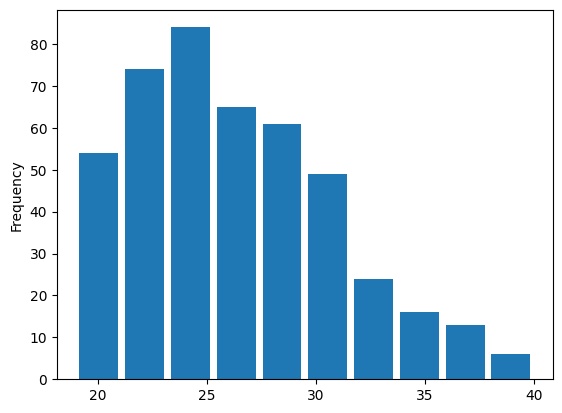

In [16]:
df['Age'].plot(kind='hist',
               rwidth=0.85)

<Axes: xlabel='Frequency'>

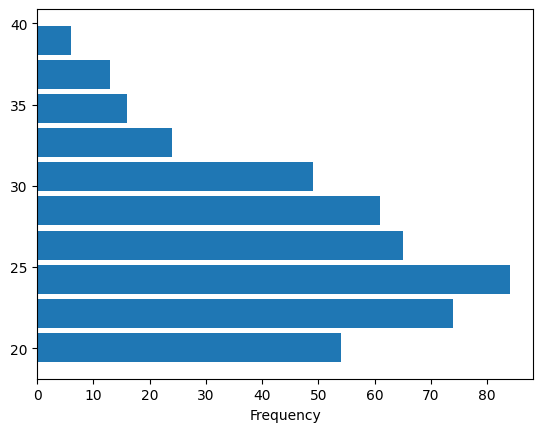

In [17]:
df['Age'].plot(kind='hist',
               rwidth=0.85,
               orientation='horizontal')

# Mathematical Examples
`plt.plot()` accepts many parameters, but the first two ones are the most important ones: the values for the `X` and `Y` axes.

Let's make a plot showing $f(x) = x^2$:

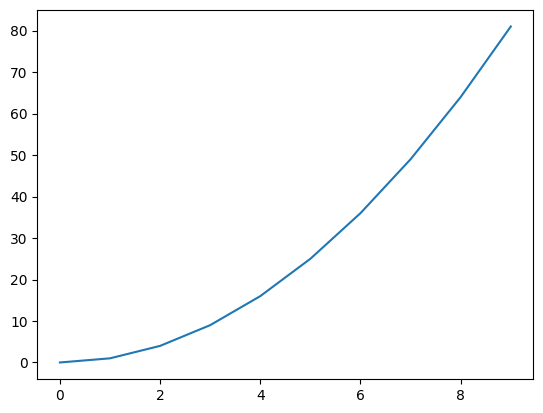

In [18]:
x_values = np.arange(10)
y_values = [value ** 2 for value in x_values]

plt.plot(x_values, y_values)

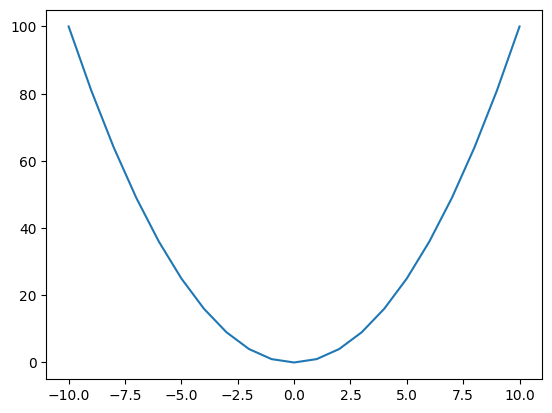

In [19]:
x_values = np.arange(-10, 11)
y_values = [value ** 2 for value in x_values]

plt.plot(x_values, y_values)

We're using `matplotlib`'s global API, which is horrible but it's the most popular one. We'll learn later how to use the _OOP_ API which will make our work much easier.

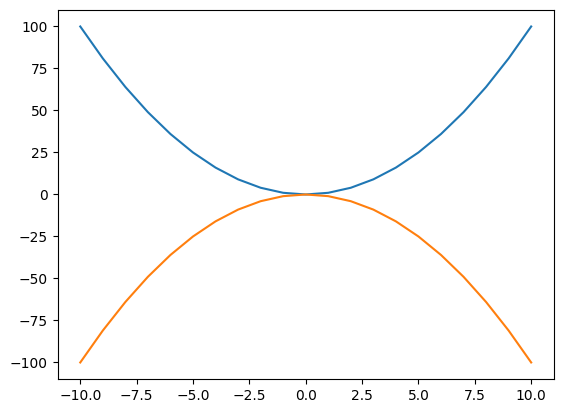

In [20]:
plt.plot(x_values, x_values ** 2)
plt.plot(x_values, -1 * (x_values ** 2))

Each `plt` function alters the global state. If you want to set settings of your plot you can use the `plt.figure` function. Others like `plt.title` keep altering the global plot:

Go a step further and:
- Plot sine and cosine series.
- Add axis names.
- Add a legend.

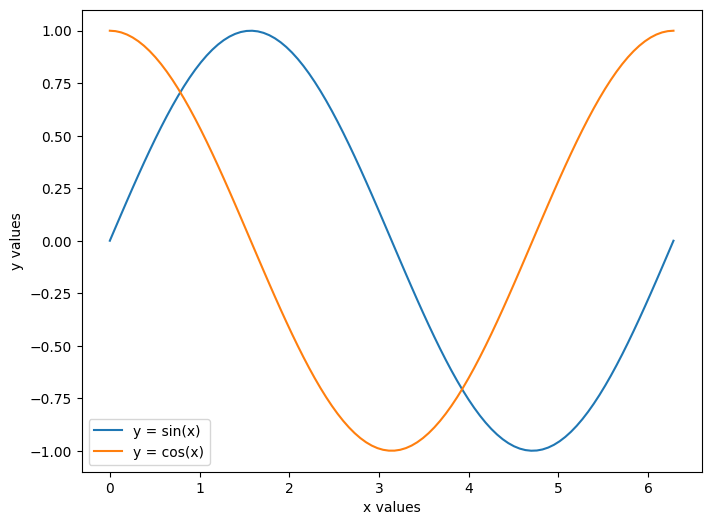

In [21]:
plt.figure(figsize=(8,6))

x_values = np.linspace(0, 2 * np.pi, 100)
sin_line, = plt.plot(x_values, np.sin(x_values))
cos_line, = plt.plot(x_values, np.cos(x_values))

plt.xlabel('x values')
plt.ylabel('y values')
plt.legend([sin_line, cos_line], ['y = sin(x)', 'y = cos(x)'])
plt.show()

### Replicating Pandas' plot with matplotlib

At its core, pandas is using matplotlib to draw the plots on screen. We can simulate the steps followed with matplotib to understand a little bit more how it works. This was our original pandas based plot:

Using matplotlib, we need to take a few more steps:

In [22]:
def backward_difference_heat_eq(nx=101, nt=1001, t0=0, tend=1, C=1.0):
    # Spatial domain
    a, b = 0.0, 1.0
    hx = (b - a) / (nx - 1)
    x = np.linspace(a, b, nx)

    # Time domain
    ht = (tend - t0) / (nt - 1)
    t = np.linspace(t0, tend, nt)

    _lambda = C * ht / hx**2

    # Source function
    def g(x, t):
        return 0.0

    # Initialize solution array
    u = np.zeros((nx, nt))
    u[:, 0] = np.sin(np.pi * x)   # Initial condition
    u[0, :] = 0                    # Boundary at x=0
    u[-1, :] = 0                   # Boundary at x=L

    # Construct tridiagonal matrix A (constant)
    A = np.zeros((nx-2, nx-2))
    for i in range(nx-2):
        if i == 0:
            A[i, i] = 1 + 2*_lambda
            A[i, i+1] = -_lambda
        elif i == nx-3:
            A[i, i-1] = -_lambda
            A[i, i] = 1 + 2*_lambda
        else:
            A[i, i-1] = -_lambda
            A[i, i] = 1 + 2*_lambda
            A[i, i+1] = -_lambda

    # Initial b vector
    gvec = np.array([g(x[i+1], t[1]) for i in range(nx-2)])
    b = u[1:-1, 0] + gvec * ht

    # Time stepping
    for k in range(1, nt):
        # Update for boundary conditions
        b[0] += u[0, k]
        b[-1] += u[-1, k]

        # Solve the linear system
        z = np.linalg.solve(A, b)

        # Update solution
        u[1:-1, k] = z

        # Update source for next time step
        if k+1 < nt:
            gvec = np.array([g(x[i+1], t[k+1]) for i in range(nx-2)])
            b = z + gvec * ht

    return x, t, u

# Run the solver
x, t, u_Bfd = backward_difference_heat_eq()

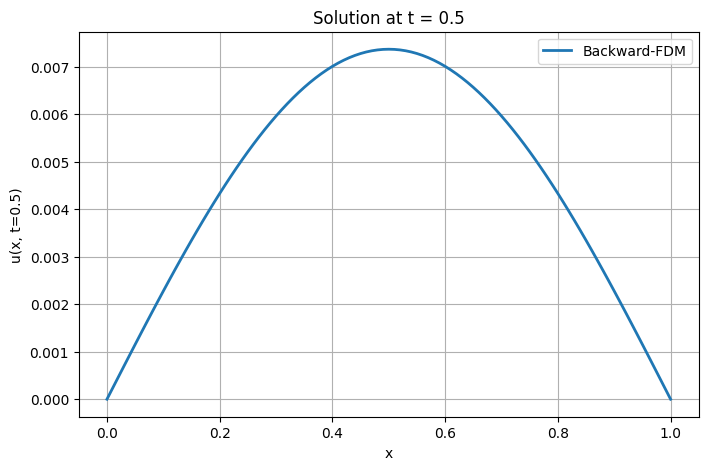

In [23]:
# -------------------------------
# Plot at t = 0.5
# -------------------------------

plt.figure(figsize=(8, 5))
plt.plot(x, u_Bfd[:, 500], label='Backward-FDM',linewidth=2)
plt.xlabel("x")
plt.ylabel("u(x, t=0.5)")
plt.title("Solution at t = 0.5")
plt.legend()
plt.grid(True)
plt.show()

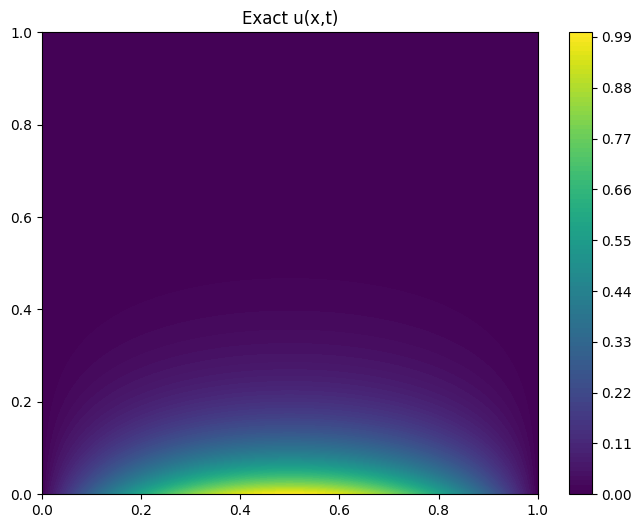

In [24]:
x_test = np.linspace(0, 1, 100).reshape(-1, 1)
t_test = np.linspace(0, 1, 100).reshape(-1, 1)
X, T = np.meshgrid(x_test.squeeze(), t_test.squeeze(), indexing="ij")
u_exact = np.sin(np.pi * X) * np.exp(-np.pi**2 * T)

plt.figure(figsize=(8, 6))
plt.title("Exact u(x,t)")
plt.contourf(X, T, u_exact, 100, cmap='viridis')
plt.colorbar()
plt.savefig("exact_u_plot.png", dpi=300, bbox_inches='tight') 
plt.show()


### Saving the plot

Plots can be saved into images of multiple formats with the `plt.savefig` function: